In [1]:
#    Define input file for BOUT++

import numpy as np
import scipy
import xbout
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
plt.rcParams["animation.html"] = "jshtml"
plt.rcParams['figure.dpi'] = 200  
plt.ioff()
#%load_ext autoreload
#%autoreload 2
params = {'legend.fontsize': 8,
'legend.title_fontsize': 8,
'figure.figsize': (4.8, 4.8),
'axes.labelsize': 12,
'axes.titlesize': 15,
'xtick.labelsize':8,
'ytick.labelsize':8,
'font.family': 'serif',
'text.usetex': False}
plt.rcParams.update(params)

In [25]:
#LOAD MANUAL STUFF
offset=3
maindir="/u/toto/soft/hermes-2-new/hermes-2/MMS/4th_order_operators/"
gridfilename=maindir+"MMS_straight_slab_16_24_16.fci.grid.nc"
df=xbout.open_boutdataset(datapath=maindir+"data_5/"+"BOUT.dmp.nc",
                          gridfilepath=gridfilename,geometry="fci").isel(x=slice(offset,-offset))
grid = xr.open_dataset(gridfilename).isel(x=slice(offset,-offset))

Applying fci geometry conventions
Read in:
<xbout.BoutDataset>
Contains:
<xarray.Dataset>
Dimensions:             (x: 16, y: 24, z: 16, t: 101)
Coordinates:
    dx                  (x, y, z) float64 dask.array<chunksize=(16, 24, 16), meta=np.ndarray>
    dy                  (x, y, z) float64 dask.array<chunksize=(16, 24, 16), meta=np.ndarray>
    dz                  (x, y, z) float64 dask.array<chunksize=(16, 24, 16), meta=np.ndarray>
  * t                   (t) float64 0.0 0.3142 0.6283 ... 30.79 31.1 31.42
    R                   (x, y, z) float64 -0.625 -0.625 -0.625 ... 0.625 0.625
    Z                   (x, y, z) float64 -0.4688 -0.4062 ... 0.4062 0.4688
  * x                   (x) int64 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15
  * y                   (y) float64 0.1309 0.3927 0.6545 ... 5.629 5.89 6.152
  * z                   (z) float64 0.0 0.3927 0.7854 1.178 ... 5.105 5.498 5.89
Data variables: (12/37)
    Bxy                 (x, y, z) float64 dask.array<chunksize=(16, 24, 16),

<IPython.core.display.Javascript object>


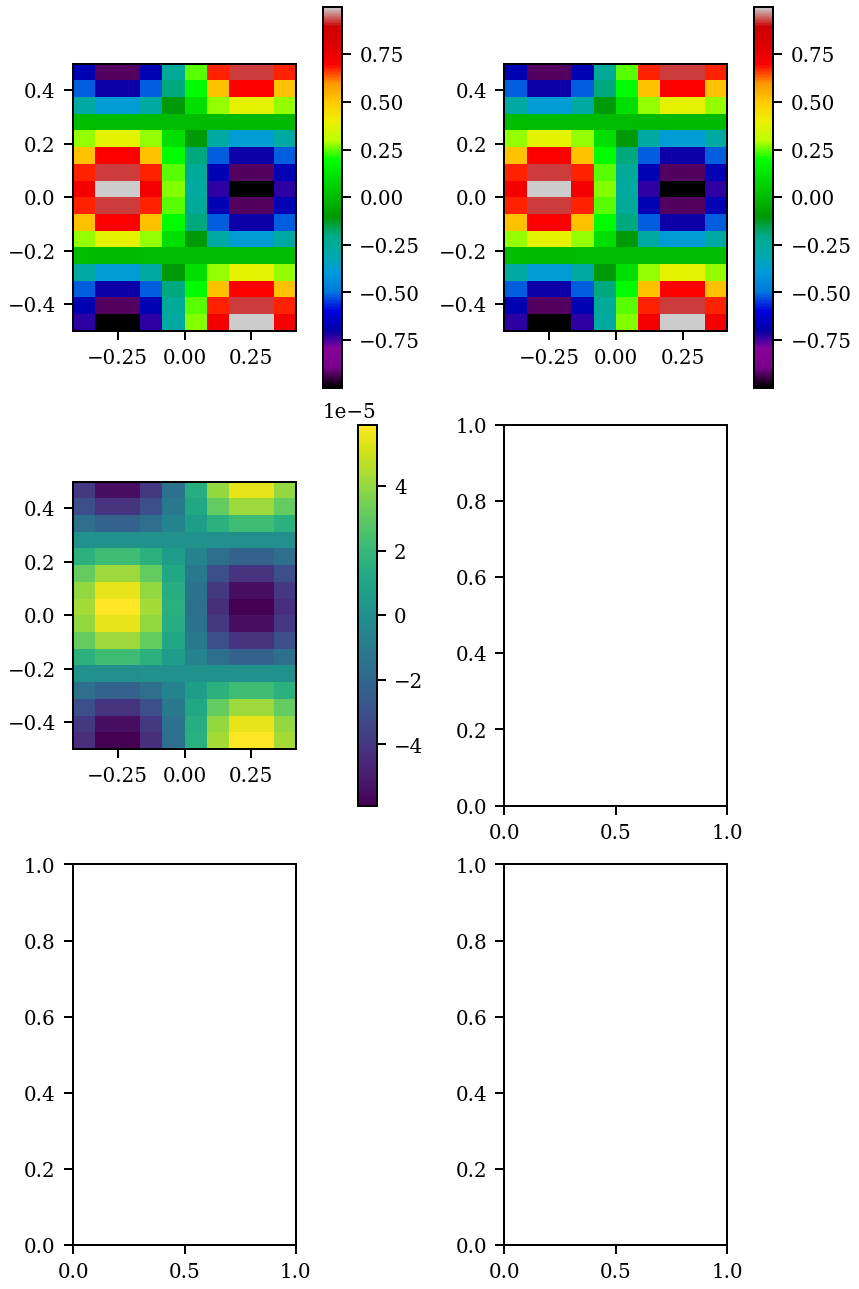

In [26]:
%matplotlib notebook
plt.close()
thist=-4
thisy=16

Field="Ne_2nd"
df_solution=df[Field]-df["E_"+Field]
vmin=np.min(df_solution.isel(y=thisy,t=thist).values)
vmax=np.max(df_solution.isel(y=thisy,t=thist).values)
fig,((ax1,ax2),(ax3,ax4),(ax5,ax6)) = plt.subplots(3,2,figsize=(4.8,3*2.4),layout="constrained")
a=ax1.pcolormesh(df.R.isel(y=thisy),df.Z.isel(y=thisy),df[Field].isel(y=thisy,t=thist),vmin=vmin,vmax=vmax,cmap="nipy_spectral")
b=ax2.pcolormesh(df.R.isel(y=thisy),df.Z.isel(y=thisy),df_solution.isel(y=thisy,t=thist),vmin=vmin,vmax=vmax,cmap="nipy_spectral")
c=ax3.pcolormesh(df.R.isel(y=thisy),df.Z.isel(y=thisy),df["E_"+Field].isel(y=thisy,t=thist))
ax1.set_aspect("equal")
ax2.set_aspect("equal")
ax3.set_aspect("equal")
plt.colorbar(a)
plt.colorbar(b)
plt.colorbar(c)

plt.show()

<IPython.core.display.Javascript object>


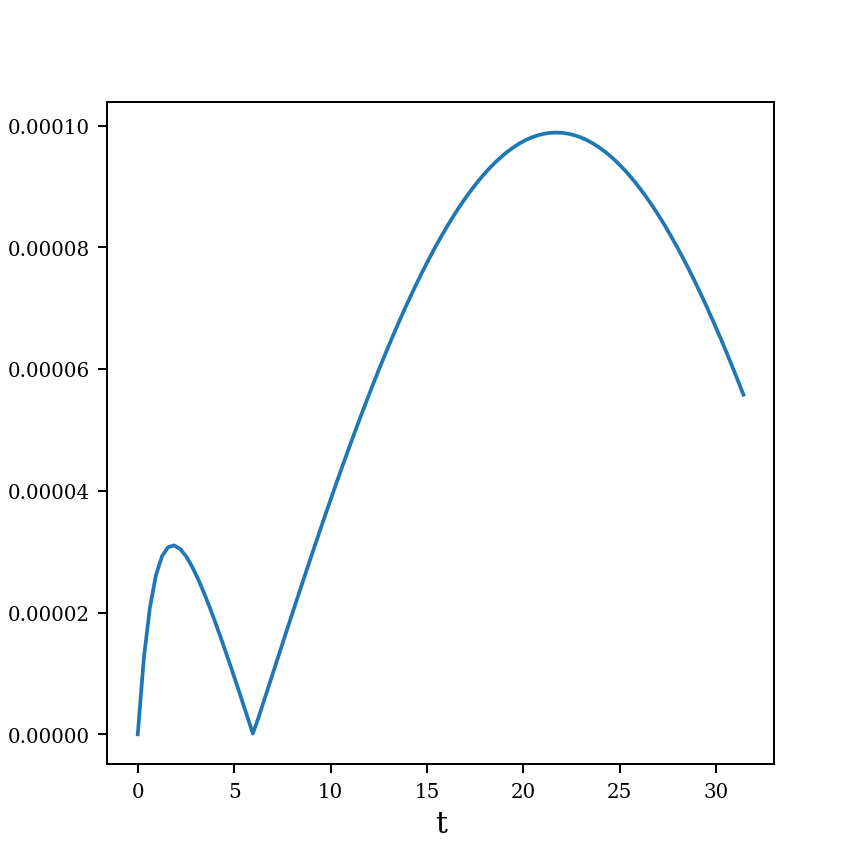

In [27]:
%matplotlib notebook

Field="Ne_2nd"
plt.figure()
(abs(df["E_"+Field])).max(dim=("x","y","z")).plot()

<IPython.core.display.Javascript object>


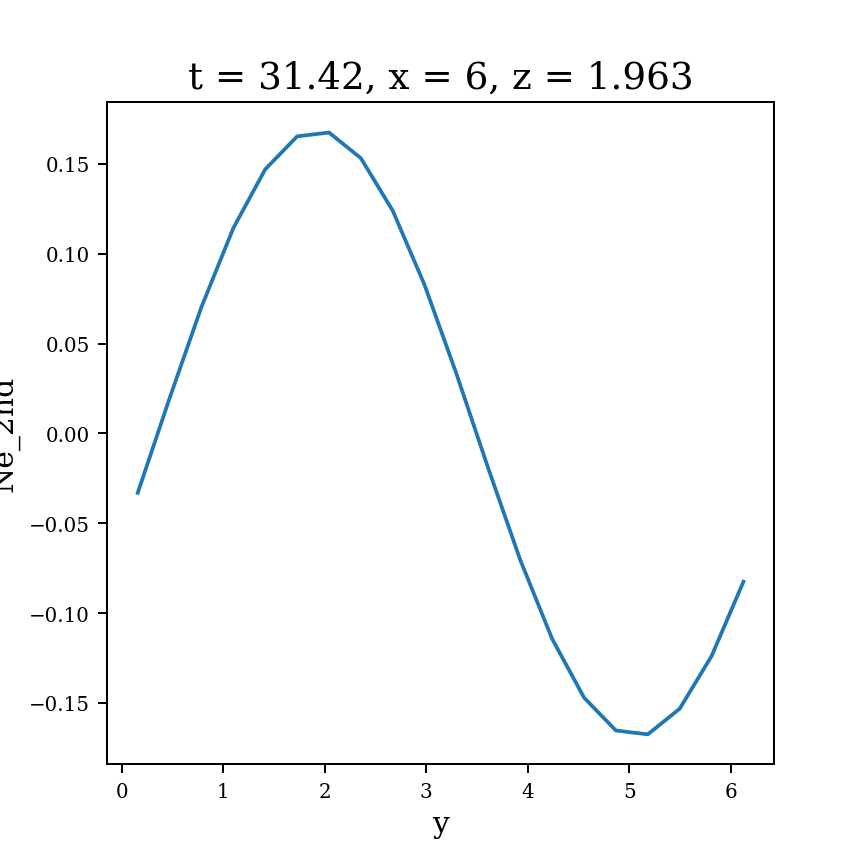

In [19]:
plt.figure()
df["Ne_2nd"].isel(x=4,z=5,t=-1).plot()

<IPython.core.display.Javascript object>


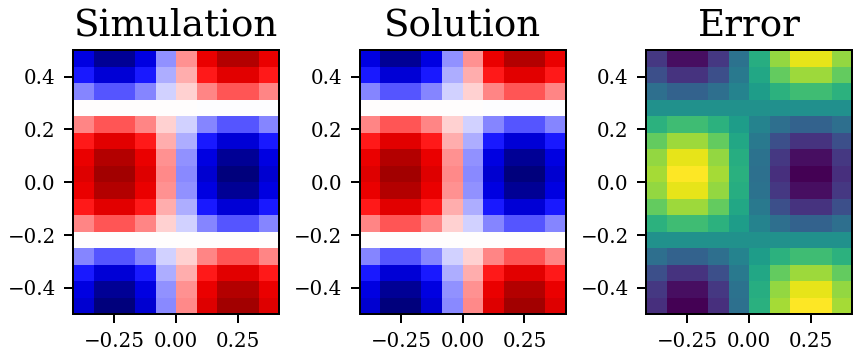

In [9]:
from matplotlib.animation import FuncAnimation
fig, (ax1,ax2,ax3) = plt.subplots(1,3,figsize=(4.8,2.0),layout="constrained")
line, = ax1.plot([], [], lw=2)  # Create an empty line object to update during animation

thisy=32
# Define the initialization function
def init():
    line.set_data([], [])
    return line,

Field = "Ne_2nd"
# Define the update function for each frame
def update(frame):
    ax1.cla()
    ax2.cla()
    ax3.cla()
    vmin=np.min(df_solution.isel(y=thisy).values)
    vmax=np.max(df_solution.isel(y=thisy).values)
    ax1.set_title("Simulation")
    ax2.set_title("Solution")
    ax3.set_title("Error")
    ax1.pcolormesh(df.R.isel(y=thisy),df.Z.isel(y=thisy),df[Field].isel(y=thisy,t=frame),vmin=vmin,vmax=vmax,cmap="seismic")
    ax2.pcolormesh(df.R.isel(y=thisy),df.Z.isel(y=thisy),df_solution.isel(y=thisy,t=frame),vmin=vmin,vmax=vmax,cmap="seismic")
    ax3.pcolormesh(df.R.isel(y=thisy),df.Z.isel(y=thisy),df["E_"+Field].isel(y=thisy,t=frame))
    
    return line,

# Set up and run the animation
frames = (df["t"].size)  # Number of time steps
anim = FuncAnimation(fig, update, frames=frames, init_func=init, blit=True,interval=100)
#anim.save("/u/toto/MMS_Loki/animation.gif", writer="pillow", fps=10)
# Display the animation in the notebook
from IPython.display import HTML
HTML(anim.to_jshtml())

In [2]:

def write_BOUT_inp(grid,solution,source,Dgrad=1.0):
    # Normalization, beacuse x does indeed not go from 0 to 1, this screws up
    # the calculation for the perp derivatives
    

    
    cont = f"""
nout = 100
timestep = (10.0*pi)/nout

grid = {grid}

xl=x
yl=y
zl=z
Dgrad={Dgrad}
[mesh:paralleltransform]
type = fci


[input]
error_on_unused_options=false


[mesh]

symmetricGlobalX = true

extrapolate_y = false

##################################################
[mesh:ddx]   # Methods used for perp (x) derivative terms

first = C2
second = C2
upwind = U1
flux = SPLIT

[mesh:ddy]   # Methods used for parallel (y) derivative terms

first = C4
second = C4
upwind = U1
flux = SPLIT

[mesh:ddz]   # Methods used for perp (z) derivative terms

first = C2
second = C2
upwind = U1
flux = SPLIT

[solver]

mms = true
mms_initialise = true
atol = 1e-15 # absolute tolerance
rtol = 1e-12  # relative tolerance
mxstep = 1000000


[Ne_2nd]

bndry_xin = neumann
bndry_xout = neumann
bndry_par_all = parallel_neumann_o1


solution = {solution}

source = {source}
[Ne_4th]

bndry_xin = dirichlet(Ne_4th:solution)
bndry_xout = dirichlet(Ne_4th:solution)
bndry_par_all = parallel_dirichlet_o2(Ne_4th:solution)

solution = {solution}

source = {source}



    """
    return cont

def read_solution_source():
    with open(f"solution.txt", "r") as file:
        solution = file.read()
        
    with open(f"source.txt", "r") as file:
        source = file.read()
    
    return solution,source

def gridfile_string(nx,ny,nz,directory):
    content = f"{directory}MMS_straight_slab_{nx}_{ny}_{nz}.fci.grid.nc"
    return content

In [3]:
grids=[]
grids.append([16,4,16])
grids.append([16,8,16])
grids.append([16,12,16])
grids.append([16,16,16])
grids.append([16,20,16])
grids.append([16,24,16])
grids.append([16,32,16])
grids.append([16,48,16])
grids.append([16,64,16])
grids.append([16,96,16])
grids.append([16,128,16])

maindir="/u/toto/soft/hermes-2-new/hermes-2/MMS/4th_order_operators/"

In [4]:
for i in range(len(grids)):
    gridfilename=gridfile_string(grids[i][0],grids[i][1],grids[i][2],maindir)
    solution_Ne,source_Ne=read_solution_source()
    BOUTinp=write_BOUT_inp(gridfilename,solution_Ne,source_Ne)
    with open(f"data_{int(i)}/BOUT.inp", "w") as file:
        file.write(BOUTinp)

In [29]:
analyze=True
if (analyze)==True:
    L2s={}
    L2infs={}
    fitcofs={}
    vars=["Ne_2nd","Ne_4th"]
    for var in vars:
        L2={}
        Linf={}
        yspacings={}
        xfit=[]
        yfit=[]
        for i in [1,2,3,4,5,6,7]: 
            id = i
            #try:
            gridfilename=gridfile_string(grids[i][0],grids[i][1],grids[i][2],maindir)
            results=xbout.open_boutdataset(datapath=f"{maindir}/data_{i}/BOUT.dmp.nc",
                                  gridfilepath=gridfilename,geometry="fci")
            yspacings[str(id)]=results.y.size
            xfit.append(results.y.size)
            nt=results["t"].size
            t2=None
            xcut=4
            L2[str(id)]=np.sqrt(((results["E_"+var])**2).isel(x=slice(xcut,-xcut),t=slice(None,t2),z=slice(xcut,-xcut)).mean()).values
            yfit.append(L2[str(id)])
            Linf[str(id)]=results["E_"+var].isel(x=slice(xcut,-xcut),t=slice(None,t2),z=slice(xcut,-xcut)).max()
            #except:
                #print(f"Failed at {i}")

        initial_guesses = [5, -4.0]
        xfit=1.0/np.array(xfit)
        yfit=np.array(yfit)

        def fitfunction(x,a,b):
            return a*x**b

        popt_N, pcov_N = curve_fit(fitfunction, xfit,yfit, maxfev=1000,p0=initial_guesses)
        L2s[var]=L2
        L2infs[var]=Linf
        fitcofs[var]=popt_N



Applying fci geometry conventions
Read in:
<xbout.BoutDataset>
Contains:
<xarray.Dataset>
Dimensions:             (x: 16, y: 8, z: 16, t: 101)
Coordinates:
    dx                  (x, y, z) float64 dask.array<chunksize=(16, 8, 16), meta=np.ndarray>
    dy                  (x, y, z) float64 dask.array<chunksize=(16, 8, 16), meta=np.ndarray>
    dz                  (x, y, z) float64 dask.array<chunksize=(16, 8, 16), meta=np.ndarray>
  * t                   (t) float64 0.0 0.3142 0.6283 ... 30.79 31.1 31.42
    R                   (x, y, z) float64 -0.625 -0.625 -0.625 ... 0.625 0.625
    Z                   (x, y, z) float64 -0.4688 -0.4062 ... 0.4062 0.4688
  * x                   (x) int64 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15
  * y                   (y) float64 0.3927 1.178 1.963 2.749 ... 4.32 5.105 5.89
  * z                   (z) float64 0.0 0.3927 0.7854 1.178 ... 5.105 5.498 5.89
Data variables: (12/37)
    Bxy                 (x, y, z) float64 dask.array<chunksize=(16, 8, 16), m

Applying fci geometry conventions
Read in:
<xbout.BoutDataset>
Contains:
<xarray.Dataset>
Dimensions:             (x: 16, y: 24, z: 16, t: 101)
Coordinates:
    dx                  (x, y, z) float64 dask.array<chunksize=(16, 24, 16), meta=np.ndarray>
    dy                  (x, y, z) float64 dask.array<chunksize=(16, 24, 16), meta=np.ndarray>
    dz                  (x, y, z) float64 dask.array<chunksize=(16, 24, 16), meta=np.ndarray>
  * t                   (t) float64 0.0 0.3142 0.6283 ... 30.79 31.1 31.42
    R                   (x, y, z) float64 -0.625 -0.625 -0.625 ... 0.625 0.625
    Z                   (x, y, z) float64 -0.4688 -0.4062 ... 0.4062 0.4688
  * x                   (x) int64 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15
  * y                   (y) float64 0.1309 0.3927 0.6545 ... 5.629 5.89 6.152
  * z                   (z) float64 0.0 0.3927 0.7854 1.178 ... 5.105 5.498 5.89
Data variables: (12/37)
    Bxy                 (x, y, z) float64 dask.array<chunksize=(16, 24, 16),

Applying fci geometry conventions
Read in:
<xbout.BoutDataset>
Contains:
<xarray.Dataset>
Dimensions:             (x: 16, y: 8, z: 16, t: 101)
Coordinates:
    dx                  (x, y, z) float64 dask.array<chunksize=(16, 8, 16), meta=np.ndarray>
    dy                  (x, y, z) float64 dask.array<chunksize=(16, 8, 16), meta=np.ndarray>
    dz                  (x, y, z) float64 dask.array<chunksize=(16, 8, 16), meta=np.ndarray>
  * t                   (t) float64 0.0 0.3142 0.6283 ... 30.79 31.1 31.42
    R                   (x, y, z) float64 -0.625 -0.625 -0.625 ... 0.625 0.625
    Z                   (x, y, z) float64 -0.4688 -0.4062 ... 0.4062 0.4688
  * x                   (x) int64 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15
  * y                   (y) float64 0.3927 1.178 1.963 2.749 ... 4.32 5.105 5.89
  * z                   (z) float64 0.0 0.3927 0.7854 1.178 ... 5.105 5.498 5.89
Data variables: (12/37)
    Bxy                 (x, y, z) float64 dask.array<chunksize=(16, 8, 16), m

Applying fci geometry conventions
Read in:
<xbout.BoutDataset>
Contains:
<xarray.Dataset>
Dimensions:             (x: 16, y: 20, z: 16, t: 101)
Coordinates:
    dx                  (x, y, z) float64 dask.array<chunksize=(16, 20, 16), meta=np.ndarray>
    dy                  (x, y, z) float64 dask.array<chunksize=(16, 20, 16), meta=np.ndarray>
    dz                  (x, y, z) float64 dask.array<chunksize=(16, 20, 16), meta=np.ndarray>
  * t                   (t) float64 0.0 0.3142 0.6283 ... 30.79 31.1 31.42
    R                   (x, y, z) float64 -0.625 -0.625 -0.625 ... 0.625 0.625
    Z                   (x, y, z) float64 -0.4688 -0.4062 ... 0.4062 0.4688
  * x                   (x) int64 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15
  * y                   (y) float64 0.1571 0.4712 0.7854 ... 5.498 5.812 6.126
  * z                   (z) float64 0.0 0.3927 0.7854 1.178 ... 5.105 5.498 5.89
Data variables: (12/37)
    Bxy                 (x, y, z) float64 dask.array<chunksize=(16, 20, 16)

Applying fci geometry conventions
Read in:
<xbout.BoutDataset>
Contains:
<xarray.Dataset>
Dimensions:             (x: 16, y: 48, z: 16, t: 101)
Coordinates:
    dx                  (x, y, z) float64 dask.array<chunksize=(16, 48, 16), meta=np.ndarray>
    dy                  (x, y, z) float64 dask.array<chunksize=(16, 48, 16), meta=np.ndarray>
    dz                  (x, y, z) float64 dask.array<chunksize=(16, 48, 16), meta=np.ndarray>
  * t                   (t) float64 0.0 0.3142 0.6283 ... 30.79 31.1 31.42
    R                   (x, y, z) float64 -0.625 -0.625 -0.625 ... 0.625 0.625
    Z                   (x, y, z) float64 -0.4688 -0.4062 ... 0.4062 0.4688
  * x                   (x) int64 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15
  * y                   (y) float64 0.06545 0.1963 0.3272 ... 5.956 6.087 6.218
  * z                   (z) float64 0.0 0.3927 0.7854 1.178 ... 5.105 5.498 5.89
Data variables: (12/37)
    Bxy                 (x, y, z) float64 dask.array<chunksize=(16, 48, 16

/u/toto/conda-envs/pyenv/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: overflow encountered in square
  return func(*(_execute_task(a, cache) for a in args))


<IPython.core.display.Javascript object>


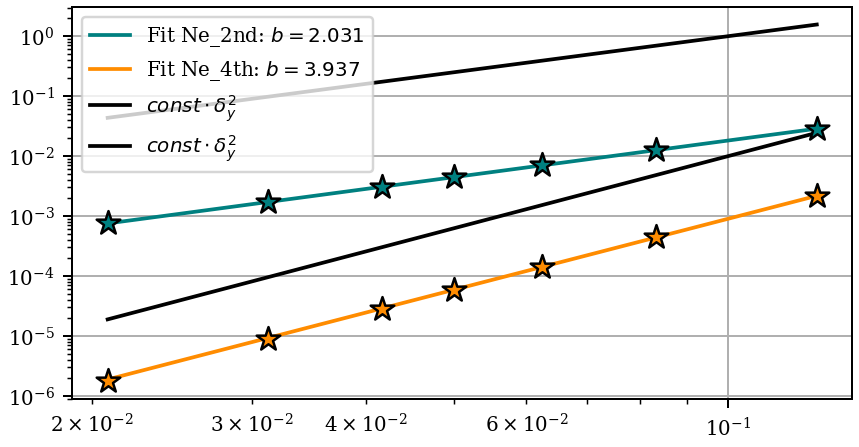

In [32]:
if (analyze)==True:
    cols={}
    cols[vars[0]]="Teal"
    cols[vars[1]]="darkorange"
    %matplotlib notebook
    plt.close()
    fig,(ax) = plt.subplots(1,1,figsize=(4.8,2.5),layout="constrained")
    for var in vars:
        L2=L2s[var]
        popt_N=fitcofs[var]
        for key in L2:
            ax.scatter(1.0/yspacings[key],L2[key],color=cols[var],marker="*",s=100,edgecolor="black",zorder=10)
        ax.plot(xfit,fitfunction(xfit, *popt_N),label=f'Fit {var}: $b={popt_N[1]:.3f}$',color=cols[var])

    
    ax.set_yscale("log")
    ax.set_xscale("log")
    ax.grid()
    ax.plot(xfit,100*xfit**2,color="black",label=r"$const \cdot \delta_y^2$")
    ax.plot(xfit,100*xfit**4,color="black",label=r"$const \cdot \delta_y^2$")
    ax.legend()
    plt.show()